# Density constraints: imaginary part of the material density

Global bound with power conservation constraints (real and imaginary part, shared projectors $P_1 = I$, $P_2 = jI$) and an additional general constraint forcing the weighted sum of the imaginary part of the inferred material density to vanish.

Material density per basis function (same as `inferredDensity` in `quadraticInferencePareto.ipynb`):
$$\rho_i = \frac{Z_s I_i}{V_i - (Z_0 I)_i}, \qquad \operatorname{Im}\rho_i = 0 \iff \operatorname{Im}\left[Z_s I_i\,(V_i - (Z_0 I)_i)^*\right] = 0 .$$
The weighted sum $\sum_i w_i \operatorname{Im}\left[Z_s I_i (V-Z_0 I)_i^*\right] = 0$ is quadratic in $I$ and enters as a general constraint $\operatorname{Re}(-I^H B I + 2 I^H s) = 0$.

In [75]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

# conda clean --all

In [76]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [77]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
# Zs = 1 / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_dipole.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

R0 = np.loadtxt(r"R0_dipole.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

X0 = np.loadtxt(r"X0_dipole.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

Vinc = np.loadtxt(r"V_dipole.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ Vinc)
Vinc = Vchol(Vinc)

Zmat = Zs * np.eye(Ndes) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix
Rmat = np.real(Zmat) # rezistivity matrix

Vzero = np.zeros((Ndes,), dtype=complex) # zero vector

Obj = -0.5 * R0
obj = Vzero/2
obj0 = 0

def evalObj(Ivec):
    return(-np.real(Ivec.conj().T @ Obj @ Ivec) + 2*np.real(Ivec.conj().T @ obj) + obj0)

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObj(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  195
Objective for full plate: 1.010821e+01 W


## QCQP with global power conservation (real + imaginary part)

Shared constraints $\operatorname{Re}\left(-I^H A_1 P_j I + 2 I^H P_j^H e\right) = 0$ with $U = j Z_\mathrm{tot}/Z_s$, $A_1 = U^H = -j Z_\mathrm{tot}^*/Z_s^*$, $e = jV/(2Z_s)$ (so $U I = 2e$) and projectors $P_j = Z_s^* p_j I$, which gives
$$\operatorname{Re}\left(j p_j^* I^H (V - Z_\mathrm{tot} I)\right) = 0 ,$$
i.e. $p_1 = 1$: reactive power, $p_2 = j$: real power conservation.

In [78]:
Umat = -1j * Ztot.conj()/np.conj(Zs)   # A1 = U^H with U = j Ztot (Ztot symmetric)
eVec = 1j * Vinc / 2/Zs

Pdiags = np.conj(Zs) * np.column_stack([np.ones(Ndes), 1j*np.ones(Ndes)]).astype(complex)  # global: Im and Re part
Plist = [sp.diags(Pdiags[:, i]) for i in range(Pdiags.shape[1])]

Bmat = Obj
bVec = obj
beta = obj0

def projRes(I, p):
    # residual of the shared constraint with projector diagonal p
    return np.real(-I.conj() @ (Umat @ (p*I)) + 2*I.conj() @ (np.conj(p)*eVec))

print("power conservation residuals at full plate:", [f"{projRes(Ifull, Pdiags[:, k]):.2e}" for k in range(Pdiags.shape[1])])

power conservation residuals at full plate: ['-8.86e-12', '-1.42e-11']


## Weighted imaginary material density constraint

$$\sum_i w_i \operatorname{Im}\left[Z_s I_i (V_i - (Z_0 I)_i)^*\right]
= \operatorname{Re}\left(-I^H B I + 2 I^H s\right),\quad
B = -\operatorname{Sym}\left(j Z_s Z_0^H D_w\right),\quad s = \tfrac{j}{2} Z_s^*\, D_w V,$$
with $D_w = \operatorname{diag}(w)$. The constraint is normalized by $\|B\|_2$.

In [79]:
wDens = np.ones(Ndes)   # weights of the imaginary density sum

Bdens = -Msym(1j*Zs * Z0.conj().T @ np.diag(wDens))
sDens = 1j*np.conj(Zs) * wDens * Vinc / 2
cDens = 0.0
scDens = np.linalg.norm(Bdens, 2)
Bdens, sDens = Bdens/scDens, sDens/scDens

def densRes(I):
    return np.real(-I.conj() @ Bdens @ I + 2*I.conj() @ sDens) + cDens

def imDensSum(I):
    return np.sum(wDens*np.imag(Zs*I*np.conj(Vinc - Z0 @ I)))

print(f"density constraint residual at full plate: {densRes(Ifull):.2e} (direct {imDensSum(Ifull)/scDens:.2e})")

density constraint residual at full plate: 8.18e-16 (direct -1.06e-16)


## Dual problem

In [80]:
QCQP = DenseSharedProjQCQP(
    Bmat, bVec, beta,
    Umat, eVec,
    Plist,
    B_j=[Bdens], s_2j=[sDens], c_2j=[cDens],
    verbose=1,
)

# Sym(A1 P_2) = Re(Ztot), so a positive multiplier on the real power constraint makes A dual feasible
lags_init = np.zeros(QCQP.get_number_constraints())
lags_init[1] = 1
print(f"initial lags dual feasible: {QCQP.is_dual_feasible(lags_init)}")

opt_params = OptimizationHyperparameters(opttol=1e-6,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=10,
    penalty_ratio=1e-2,
    penalty_reduction=0.1,
    break_iter_period=5,
    verbose=0)

t1 = time.time()
result = QCQP.solve_current_dual_problem(method='newton', init_lags=lags_init, opt_params=opt_params)
print(f"bound: {result[0]:.6e} W, time: {time.time()-t1:.2f}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 3 A matrices and Fs vectors.
initial lags dual feasible: True
bound: 1.012093e+01 W, time: 0.04s, Lagrange multipliers: [ 0.03667871  0.9869755  22.7710813 ]


In [81]:
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(totalA))):.3e}")

Ivec = QCQP.current_xstar
print(f"dual bound {QCQP.current_dual:.6e} W, P(x*) {evalObj(Ivec):.6e} W, full plate {Pfull:.6e} W")
print("constraint residuals at x*:", [f"{projRes(Ivec, Pdiags[:, k]):.2e}" for k in range(Pdiags.shape[1])], f"{densRes(Ivec):.2e}")

# reference: same problem without the density constraint
QCQP0 = DenseSharedProjQCQP(Bmat, bVec, beta, Umat, eVec, Plist, verbose=0)
result0 = QCQP0.solve_current_dual_problem(method='newton', init_lags=lags_init[:2], opt_params=opt_params)
print(f"bound without density constraint: {result0[0]:.6e} W, Lagrange multipliers: {QCQP0.current_lags}")

minimum eigenvalue of A: 5.781e-01
dual bound 1.012093e+01 W, P(x*) 1.012093e+01 W, full plate 1.010821e+01 W
constraint residuals at x*: ['-5.21e-07', '-8.40e-07'] -6.53e-11
bound without density constraint: 1.012093e+01 W, Lagrange multipliers: [0.03777126 0.98806805]


## Density constraints + GCD loop

Each iteration adds a general constraint $\sum_i w_i \operatorname{Im}\left[Z_s I_i (V_i-(Z_0 I)_i)^*\right] = 0$ weighted by the pointwise error at the current $x^\star$, $w_i = \operatorname{Im}\left[Z_s x^\star_i (V_i-(Z_0 x^\star)_i)^*\right]$, and performs one GCD step with `gcd.run_gcd` (`max_gcd_iter_num=1`: dual solve, max dual gradient projector constraint, dual solve; leading projectors merged above `max_proj_cstrt_num`), warm-started from the previous multipliers with zeros for the new constraints.

In [ ]:
import copy, contextlib, io
from dolphindes.util import Sym
from dolphindes.cvxopt.gcd import GCDHyperparameters, run_gcd

def imDensErr(I):
    # pointwise error Im[Zs I_i (V_i - (Z0 I)_i)^*], zero iff Im(rho_i) = 0
    return np.imag(Zs*I*np.conj(Vinc - Z0 @ I))

def densConstraint(w):
    # general constraint  sum_i w_i Im[Zs I_i (V - Z0 I)_i^*] = 0,  normalized by ||B||_2
    B = -Msym(1j*Zs * Z0.conj().T * w[None, :])
    s = 1j*np.conj(Zs) * w * Vinc / 2
    sc = np.linalg.norm(B, 2)
    return B/sc, s/sc, 0.0ø

def addGenConstraint(Q, B, s, c):
    """Append a general constraint to Q with a zero multiplier."""
    Q.B_j.append(np.asarray(B, dtype=complex))
    Q.s_2j.append(np.asarray(s, dtype=complex))
    Q.c_2j = np.append(Q.c_2j, c)
    Q.n_gen_constr = len(Q.B_j)
    Q.precomputed_As.append(Sym(Q.A2.conj().T @ Q.B_j[-1] @ Q.A2))
    Q.Fs = np.column_stack([Q.Fs, Q.A2.conj().T @ Q.s_2j[-1]])
    Q.current_lags = np.append(Q.current_lags, 0.0)
    Q.current_grad = Q.current_hess = None
    Q._invalidate_factor_cache()

nIterDens = 30
max_proj_cstrt_num = 30

# one GCD step per call: solve dual (warm start) -> add max dual gradient projector -> solve dual
gcd_step_params = GCDHyperparameters(
    max_proj_cstrt_num=max_proj_cstrt_num,
    max_gcd_iter_num=1,
    gcd_iter_period=1,
    ortho_metric='euclidean',   # converges much faster here than the default 'hilbert_schmidt'
    method='newton',
    opt_params=opt_params,
)

dQCQP = copy.deepcopy(QCQP)
history = [(0, dQCQP.current_dual, np.linalg.norm(imDensErr(dQCQP.current_xstar)))]
t1 = time.time()
for it in range(1, nIterDens + 1):
    # density constraint weighted by the pointwise error at the current x*
    addGenConstraint(dQCQP, *densConstraint(imDensErr(dQCQP.current_xstar)))
    # one GCD step, warm started from the previous multipliers and zeros for the new constraints
    # (run_gcd keeps current_lags when dual feasible; its HS orthonormalization maps them consistently)
    with contextlib.redirect_stdout(io.StringIO()):
        run_gcd(dQCQP, gcd_params=gcd_step_params)
    err = np.linalg.norm(imDensErr(dQCQP.current_xstar))
    history.append((it, dQCQP.current_dual, err))
    print(f"[{it:2d}] bound {dQCQP.current_dual:.6e} W, {dQCQP.n_proj_constr} proj + {dQCQP.n_gen_constr} density constraints, "
          f"||Im density err|| {err:.3e}, {time.time()-t1:.2f}s", flush=True)

history = np.array(history)
print(f"bound: {history[0, 1]:.6e} -> {history[-1, 1]:.6e} W (full plate {Pfull:.6e} W)")

[ 1] bound 1.011319e+01 W, 3 proj + 2 density constraints, ||Im density err|| 1.166e-02, 0.13s
[ 2] bound 1.011317e+01 W, 4 proj + 3 density constraints, ||Im density err|| 1.039e-02, 0.22s
[ 3] bound 1.011302e+01 W, 5 proj + 4 density constraints, ||Im density err|| 2.384e-02, 0.36s
[ 4] bound 1.011231e+01 W, 6 proj + 5 density constraints, ||Im density err|| 3.366e-02, 0.87s
[ 5] bound 1.011128e+01 W, 7 proj + 6 density constraints, ||Im density err|| 3.787e-02, 1.14s
[ 6] bound 1.011109e+01 W, 8 proj + 7 density constraints, ||Im density err|| 1.757e-02, 1.28s
[ 7] bound 1.011103e+01 W, 9 proj + 8 density constraints, ||Im density err|| 1.200e-02, 1.44s
[ 8] bound 1.011099e+01 W, 10 proj + 9 density constraints, ||Im density err|| 1.124e-02, 1.60s
[ 9] bound 1.011095e+01 W, 11 proj + 10 density constraints, ||Im density err|| 1.212e-02, 1.79s
[10] bound 1.011085e+01 W, 12 proj + 11 density constraints, ||Im density err|| 1.513e-02, 2.06s
[11] bound 1.011070e+01 W, 13 proj + 12 densi

## Inferred complex material density

initial: Re rho in [-0.264, 1.228], Im rho in [-0.178, 0.710], ||Im rho||/||rho|| 5.454e-01
density + GCD: Re rho in [-0.371, 1.719], Im rho in [-0.274, 1.549], ||Im rho||/||rho|| 6.733e-01


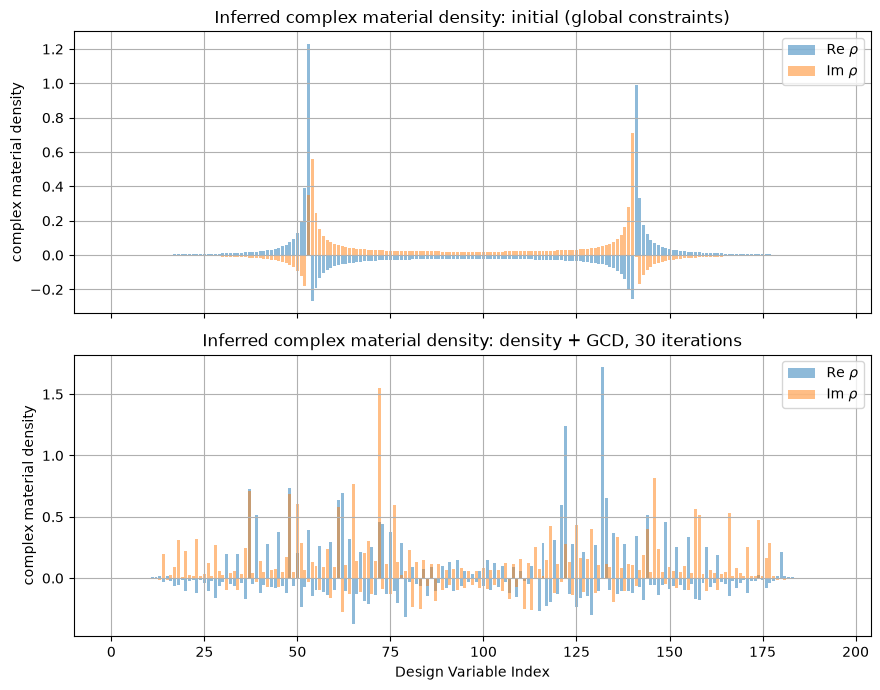

In [83]:
import matplotlib.pyplot as plt

def complexDensity(I):
    # inferred complex material density rho = Zs I / (V - Z0 I) (Cholesky space)
    return Zs*I/(Vinc - Z0 @ I)

rhoInit = complexDensity(QCQP.current_xstar)    # global constraints + one density constraint
rhoOpt = complexDensity(dQCQP.current_xstar)    # after the density + GCD loop
for name, rho in [("initial", rhoInit), ("density + GCD", rhoOpt)]:
    print(f"{name}: Re rho in [{rho.real.min():.3f}, {rho.real.max():.3f}], "
          f"Im rho in [{rho.imag.min():.3f}, {rho.imag.max():.3f}], ||Im rho||/||rho|| {np.linalg.norm(rho.imag)/np.linalg.norm(rho):.3e}")

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for ax, (name, rho) in zip(axes, [("initial (global constraints)", rhoInit), (f"density + GCD, {nIterDens} iterations", rhoOpt)]):
    ax.bar(np.arange(Ndes), np.real(rho), alpha=0.5, label=r'Re $\rho$')
    ax.bar(np.arange(Ndes), np.imag(rho), alpha=0.5, label=r'Im $\rho$')
    ax.set_ylabel('complex material density'); ax.set_title(f'Inferred complex material density: {name}')
    ax.legend(); ax.grid(True)
axes[-1].set_xlabel('Design Variable Index')
plt.tight_layout(); plt.show()